# DO Emulation & Calibration — Scaled Input/Output Experiment

Experimental notebook: mirrors `DO_emulate_calibrate.ipynb` but adopts the
scaling strategy from `SBI_calibration.ipynb`:

- **Inputs** scaled to **[0, 1]** using the fixed *prior bounds* (not data min/max).
- **Outputs** standardised to **N(0, 1)** with a `StandardScaler`.
- **MCMC** samples directly in **[0, 1]** — no log-transform, no Jacobian.
  Prior: multivariate KDE on the filtered training set (n_DO ≥ 20), evaluated in physical space.
- Training and inference use only runs with **n\\_do\\_events ≥ 20**.

Nothing here is committed to `gp_emulator.py` or `mcmc.py`; the custom classes
(`BoundsScaler`, `ScaledEmulatorMCMC`) live inline for easy experimentation.

## 1. Configuration

In [1]:
# ── Dataset configuration ─────────────────────────────────────────────────────
PPE_CONFIGS = {
    'data': {
        'data_dir':          'data',
        'run_length':        75000,
        'spinup_fraction':   0.02,
        'do_crossing_value': 5.0,
        'detection_mode':    'peak_walkback',
        'do_peak_threshold': 14.0,
        'prior_bounds': {
            'diff_dia_min':  (7.5e-6,   1.25e-5),
            'drag_topo_fac': (2.25,     3.75),
            'slope_max':     (7.5e-4,   1.25e-3),
            'diff_iso':      (1125,     1875),
            'diff_gm':       (1125,     1875),
            'diff_dia_max':  (1.125e-4, 1.875e-4),
        },
    },
    'data2': {
        'data_dir':          'data2',
        'run_length':        10000,
        'spinup_fraction':   0.1,
        'do_crossing_value': 3.6,
        'detection_mode':    'peak_walkback',
        'do_peak_threshold': 14.0,
        'prior_bounds': {
            'diff_dia_min':  (0.5e-5,  2.0e-5),
            'drag_topo_fac': (2.5,     3.5),
            'slope_max':     (0.5e-3,  2.0e-3),
            'diff_iso':      (500,     2000),
            'diff_gm':       (500,     2000),
            'diff_dia_max':  (1.0e-4,  2.0e-4),
        },
    },
}

ACTIVE_DATASET = 'data'   # ← change here to switch

DEFAULT_RUN_FILE = '../emulator/climberx_output/default_long_run/ocn_ts.nc'

N_PCA = 5

# n_do_events threshold — only runs with at least this many DO events are used
N_DO_THRESHOLD = 27

# ─────────────────────────────────────────────────────────────────────────────
cfg               = PPE_CONFIGS[ACTIVE_DATASET]
DATA_DIR          = cfg['data_dir']
spinup_fraction   = cfg['spinup_fraction']
do_crossing_value = cfg['do_crossing_value']
detection_mode    = cfg['detection_mode']
do_peak_threshold = cfg['do_peak_threshold']
prior_bounds      = cfg['prior_bounds']
param_names       = list(prior_bounds.keys())

print(f'Active dataset  : {ACTIVE_DATASET} ({DATA_DIR})')
print(f'Run length      : {cfg["run_length"]} yr')
print(f'n_DO threshold  : ≥ {N_DO_THRESHOLD}')
print(f'PCA components  : {N_PCA}')

Active dataset  : data (data)
Run length      : 75000 yr
n_DO threshold  : ≥ 27
PCA components  : 5


## 2. Data Loading

In [2]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import importlib

import summary_stats as _ss; importlib.reload(_ss)
from summary_stats import compute_summary_stats

import utils as _ut; importlib.reload(_ut)
from utils import (
    plot_amoc_analysis,
    plot_pca_variance, plot_pca_components,
    plot_pca_predictions, plot_stat_predictions,
    plot_pdf_comparison,
)

import gp_emulator as _gp; importlib.reload(_gp)
from gp_emulator import GPEmulatorPDF, crossvalidation, print_cv_summary

# ── Parameter table ──────────────────────────────────────────────────────────
info     = pd.read_csv(f'{DATA_DIR}/info.txt', delimiter=r'\s+')
ocn_cols = [c for c in info.columns if c.startswith('ocn.')]
if 'ocn.l_noise_fw' in ocn_cols:
    ocn_cols.remove('ocn.l_noise_fw')
params = info[['runid'] + ocn_cols]

print(f'Parameter table : {params.shape[0]} runs × {len(ocn_cols)} parameters')

Parameter table : 500 runs × 6 parameters


In [3]:
# ── Build file list ───────────────────────────────────────────────────────────
run_ids_in_dir = sorted(
    int(d) for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d)) and d.isdigit()
)
max_run_id = max(run_ids_in_dir)

model_files = []
for run_id in range(1, max_run_id + 1):
    fp = f'{DATA_DIR}/{run_id}/ocn_ts.nc'
    model_files.append(fp if os.path.exists(fp) else None)

print(f'Found {len(run_ids_in_dir)} run directories')

Found 500 run directories


## 3. Summary Statistics & PCA

In [4]:
from tqdm.notebook import tqdm
from sklearn.decomposition import PCA

expected_length = cfg['run_length']

# ── Pass 1: collect global AMOC range ────────────────────────────────────────
all_amoc_concat = []
incomplete_run_ids = []

if os.path.exists(DEFAULT_RUN_FILE):
    ds = xr.open_dataset(DEFAULT_RUN_FILE)
    amoc_default_raw = ds.amoc26N.values
    time_default_raw = ds.time.values
    ds.close()
    s0 = int(len(amoc_default_raw) * 0.02)
    all_amoc_concat.append(amoc_default_raw[s0:])
    print(f'Default run loaded: {len(amoc_default_raw)} yr')
else:
    amoc_default_raw = None
    print(f'WARNING: default run not found at {DEFAULT_RUN_FILE!r}')

for i, file in enumerate(tqdm(model_files, desc='Pass 1')):
    if file is None:
        continue
    ds = xr.open_dataset(file)
    amoc = ds.amoc26N.values
    ds.close()
    if len(amoc) < expected_length:
        incomplete_run_ids.append(i + 1)
        model_files[i] = None
    else:
        s = int(len(amoc) * spinup_fraction)
        all_amoc_concat.append(amoc[s:])

print(f'Incomplete runs excluded: {incomplete_run_ids}')

all_amoc_flat = np.concatenate(all_amoc_concat)
global_min    = np.percentile(all_amoc_flat, 1)
global_max    = np.percentile(all_amoc_flat, 99)
global_x_grid = np.linspace(global_min, global_max, 100)

print(f'Global AMOC range (1–99th pct): [{global_min:.2f}, {global_max:.2f}] Sv')

Default run loaded: 75000 yr


Pass 1:   0%|          | 0/500 [00:00<?, ?it/s]

Incomplete runs excluded: [131, 136, 164, 171, 205, 405, 442, 448]
Global AMOC range (1–99th pct): [5.05, 28.57] Sv


In [5]:
# ── Default run summary stats ─────────────────────────────────────────────────
if amoc_default_raw is not None:
    default_stats = compute_summary_stats(
        amoc_default_raw, time_default_raw,
        x_grid=global_x_grid,
        spinup_fraction=0.02,
        do_crossing_value=5.0,
        detection_mode='peak_walkback',
        do_peak_threshold=do_peak_threshold,
    )
    print(f'Default run — DO: {default_stats["do_variability"]}  '
          f'n_DO={default_stats["n_do_events"]}  '
          f'wait={default_stats["avg_waiting_time"]:.0f} yr')
else:
    default_stats = None

Default run — DO: True  n_DO=51  wait=1452 yr


In [6]:
# ── Ensemble summary stats ────────────────────────────────────────────────────
ensemble_stats = []

for file in tqdm(model_files, desc='Summary stats'):
    if file is None:
        ensemble_stats.append(None)
        continue
    ds = xr.open_dataset(file)
    amoc = ds.amoc26N.values
    time = ds.time.values
    ds.close()
    stats = compute_summary_stats(
        amoc, time,
        x_grid=global_x_grid,
        spinup_fraction=spinup_fraction,
        do_crossing_value=do_crossing_value,
        detection_mode=detection_mode,
        do_peak_threshold=do_peak_threshold,
    )
    ensemble_stats.append(stats)

n_valid = sum(s is not None for s in ensemble_stats)
n_do    = sum(s is not None and s['do_variability'] for s in ensemble_stats)
print(f'Valid: {n_valid}  DO: {n_do}  non-DO: {n_valid - n_do}')

Summary stats:   0%|          | 0/500 [00:00<?, ?it/s]

Valid: 475  DO: 431  non-DO: 44


In [7]:
# ── PCA on all valid PDFs ─────────────────────────────────────────────────────
all_pdfs  = np.array([s['pdf'] for s in ensemble_stats if s is not None])
pca_model = PCA(n_components=N_PCA)
pca_model.fit(all_pdfs)

print(f'Explained variance: {pca_model.explained_variance_ratio_.round(4)}')
print(f'Total: {pca_model.explained_variance_ratio_.sum()*100:.1f} %')

for stats in ensemble_stats:
    if stats is not None:
        stats['pca_components'] = pca_model.transform(
            stats['pdf'].reshape(1, -1)
        ).flatten()

if default_stats is not None:
    default_stats['pca_components'] = pca_model.transform(
        default_stats['pdf'].reshape(1, -1)
    ).flatten()

Explained variance: [0.5517 0.1614 0.1044 0.0715 0.0362]
Total: 92.5 %


In [8]:
import joblib

joblib.dump(
    {"pca_model": pca_model, "x_grid": global_x_grid},
    "pca_model.pkl",
)
print("Saved pca_model.pkl  (pca_model + global_x_grid)")

Saved pca_model.pkl  (pca_model + global_x_grid)


## 4. Scaled Emulator

### 4.1 BoundsScaler

Unlike `MinMaxScaler`, which scales to [0, 1] based on the *observed data range*,
`BoundsScaler` maps using the **fixed prior bounds** — so the normalised
parameter space exactly equals [0, 1]^6 everywhere the prior is supported.
This makes it straightforward to place a flat Uniform([0, 1]) prior in the
MCMC step.

In [9]:
import numpy as np

class BoundsScaler:
    """Scale parameters to [0, 1] using fixed prior bounds."""

    def __init__(self, lower, upper):
        self.lower_ = np.asarray(lower, dtype=float)
        self.upper_ = np.asarray(upper, dtype=float)
        self.scale_ = self.upper_ - self.lower_

    def fit(self, X, y=None):
        return self

    def fit_transform(self, X, y=None):
        return (np.asarray(X, dtype=float) - self.lower_) / self.scale_

    def transform(self, X):
        return (np.asarray(X, dtype=float) - self.lower_) / self.scale_

    def inverse_transform(self, X_norm):
        return np.asarray(X_norm, dtype=float) * self.scale_ + self.lower_


lower = np.array([v[0] for v in prior_bounds.values()])
upper = np.array([v[1] for v in prior_bounds.values()])

bounds_scaler = BoundsScaler(lower, upper)

# Quick sanity check: prior midpoints should map to 0.5
mid = 0.5 * (lower + upper)
print('Midpoints → normalised:', bounds_scaler.transform(mid.reshape(1, -1)).flatten())

Midpoints → normalised: [0.5 0.5 0.5 0.5 0.5 0.5]


### 4.2 Training Data Preparation (n\_do\_events ≥ 20)

In [10]:
param_cols = [
    'ocn.diff_dia_min', 'ocn.drag_topo_fac', 'ocn.slope_max',
    'ocn.diff_iso', 'ocn.diff_gm', 'ocn.diff_dia_max',
]

STAT_COLS = ['mean', 'std', 'avg_stadial_duration', 'avg_waiting_time',
             'avg_amplitude', 'n_do_events']

valid_mask   = np.array([s is not None for s in ensemble_stats])
valid_stats  = [s for s in ensemble_stats if s is not None]
params_valid = params[valid_mask].reset_index(drop=True)

# DO-run mask
do_mask = np.array([s['do_variability'] for s in valid_stats])

X_do   = params_valid[param_cols].values[do_mask].astype(np.float64)
Y_do   = np.array([
    [s['mean'], s['std'], s['avg_stadial_duration'], s['avg_waiting_time'],
     s['avg_amplitude'], s['n_do_events']]
    for s in valid_stats if s['do_variability']
])
pca_do = np.array([s['pca_components'] for s in valid_stats if s['do_variability']])
pdf_do = np.array([s['pdf']            for s in valid_stats if s['do_variability']])

# Apply n_DO threshold
n_do_col = STAT_COLS.index('n_do_events')
keep     = Y_do[:, n_do_col] >= N_DO_THRESHOLD

X              = X_do[keep]
other_stats    = Y_do[keep]
pca_components = pca_do[keep]
pdf_matrix     = pdf_do[keep]

print(f'All DO runs       : {len(X_do)}')
print(f'After n_DO ≥ {N_DO_THRESHOLD}   : {len(X)}  ({(~keep).sum()} excluded)')

n_do_vals = other_stats[:, n_do_col]
print(f'n_do_events range : [{n_do_vals.min():.0f}, {n_do_vals.max():.0f}]  '
      f'median={np.median(n_do_vals):.0f}')

All DO runs       : 431
After n_DO ≥ 27   : 319  (112 excluded)
n_do_events range : [27, 70]  median=43


### 4.3 Emulator Training

In [11]:
from sklearn.gaussian_process.kernels import Matern
from sklearn.preprocessing import StandardScaler

kernel = 1.0 * Matern(length_scale=1.0, nu=1.5)

# BoundsScaler for inputs → [0,1] using prior bounds
# StandardScaler for outputs → N(0,1)  (default in GPEmulatorPDF)
# CV RMSE floor — same values as MCMC emulator (trained on same data)
_cv_rmse_pca  = np.array([0.0838, 0.0435, 0.0556, 0.0488, 0.0302])
_cv_rmse_stat = np.array([0.41,   0.45,   0.0,    283.0,  0.0,    4.8])
_min_std = np.concatenate([_cv_rmse_pca, _cv_rmse_stat])

emulator = GPEmulatorPDF(
    kernel=kernel,
    scaler_X=BoundsScaler(lower, upper),
    scaler_y=StandardScaler(),
    min_std=_min_std,
)
emulator.pca         = pca_model
emulator.pdf_xpoints = global_x_grid

print(f'Training on {len(X)} runs  (n_DO ≥ {N_DO_THRESHOLD})...')
emulator.fit(X, other_stats, pca_components)
print(f'Done: {emulator.n_pca_components} PCA + {other_stats.shape[1]} scalar outputs')

Training on 319 runs  (n_DO ≥ 27)...
Done: 5 PCA + 6 scalar outputs


### 4.4 Cross-Validation

In [12]:
print('Running 5-fold cross-validation...')

cv_results = crossvalidation(
    X=X,
    Y=other_stats,
    pca_components=pca_components,
    pdfs=pdf_matrix,
    emulator_class=GPEmulatorPDF,
    pca_model=pca_model,
    pdf_xpoints=global_x_grid,
    emulator_kwargs=dict(
        kernel=1.0 * Matern(length_scale=1.0, nu=1.5),
        scaler_X=BoundsScaler(lower, upper),
        scaler_y=StandardScaler(),
    ),
    cv=5,
    output_names=STAT_COLS,
)

print_cv_summary(cv_results, output_names=STAT_COLS)

Running 5-fold cross-validation...
CROSS-VALIDATION SUMMARY

--- PCA Components ---
  Overall RMSE : 0.0558 ± 0.0112
  PCA 1       : 0.0838 ± 0.0272
  PCA 2       : 0.0435 ± 0.0026
  PCA 3       : 0.0556 ± 0.0081
  PCA 4       : 0.0488 ± 0.0085
  PCA 5       : 0.0302 ± 0.0042

--- PDF Reconstruction ---
  RMSE         : 0.0157 ± 0.0021
  Sup-norm     : 0.1544 ± 0.0556

--- Scalar Statistics ---
  mean                     : 0.4117 ± 0.1724
  std                      : 0.4507 ± 0.0854
  avg_stadial_duration     : 115.4885 ± 11.1026
  avg_waiting_time         : 243.6749 ± 24.7851
  avg_amplitude            : 1.9211 ± 0.1505
  n_do_events              : 5.4733 ± 0.5146


In [13]:
# ── Held-out 20 % test split ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

(
    X_train, X_test,
    pca_train, pca_test,
    pdf_train, pdf_test,
    Y_train, Y_test,
) = train_test_split(
    X, pca_components, pdf_matrix, other_stats,
    test_size=0.2, random_state=42,
)

em_test = GPEmulatorPDF(
    kernel=1.0 * Matern(length_scale=1.0, nu=1.5),
    scaler_X=BoundsScaler(lower, upper),
    scaler_y=StandardScaler(),
)
em_test.pca         = pca_model
em_test.pdf_xpoints = global_x_grid
em_test.fit(X_train, Y_train, pca_train)

pca_pred, Y_pred, pca_std, Y_std = em_test.predict(X_test, return_std=True)
pdf_pred = em_test.reconstruct_pdf(pca_pred)

print(f'Test set: {len(X_test)} runs')

Test set: 64 runs


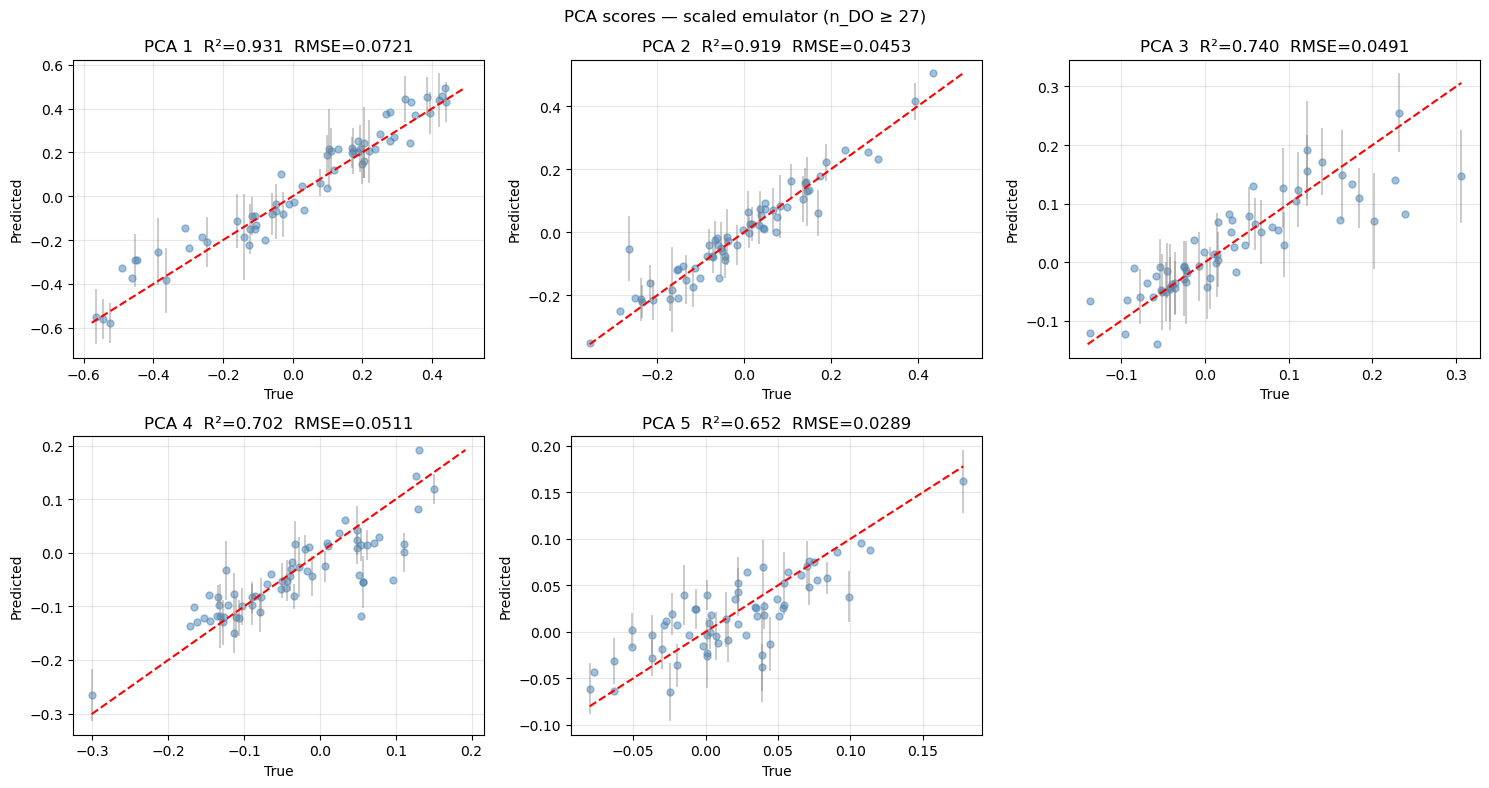

In [14]:
fig = plot_pca_predictions(pca_test, pca_pred, pca_std=pca_std)
plt.suptitle(f'PCA scores — scaled emulator (n_DO ≥ {N_DO_THRESHOLD})', fontsize=12)
plt.tight_layout()
plt.show()

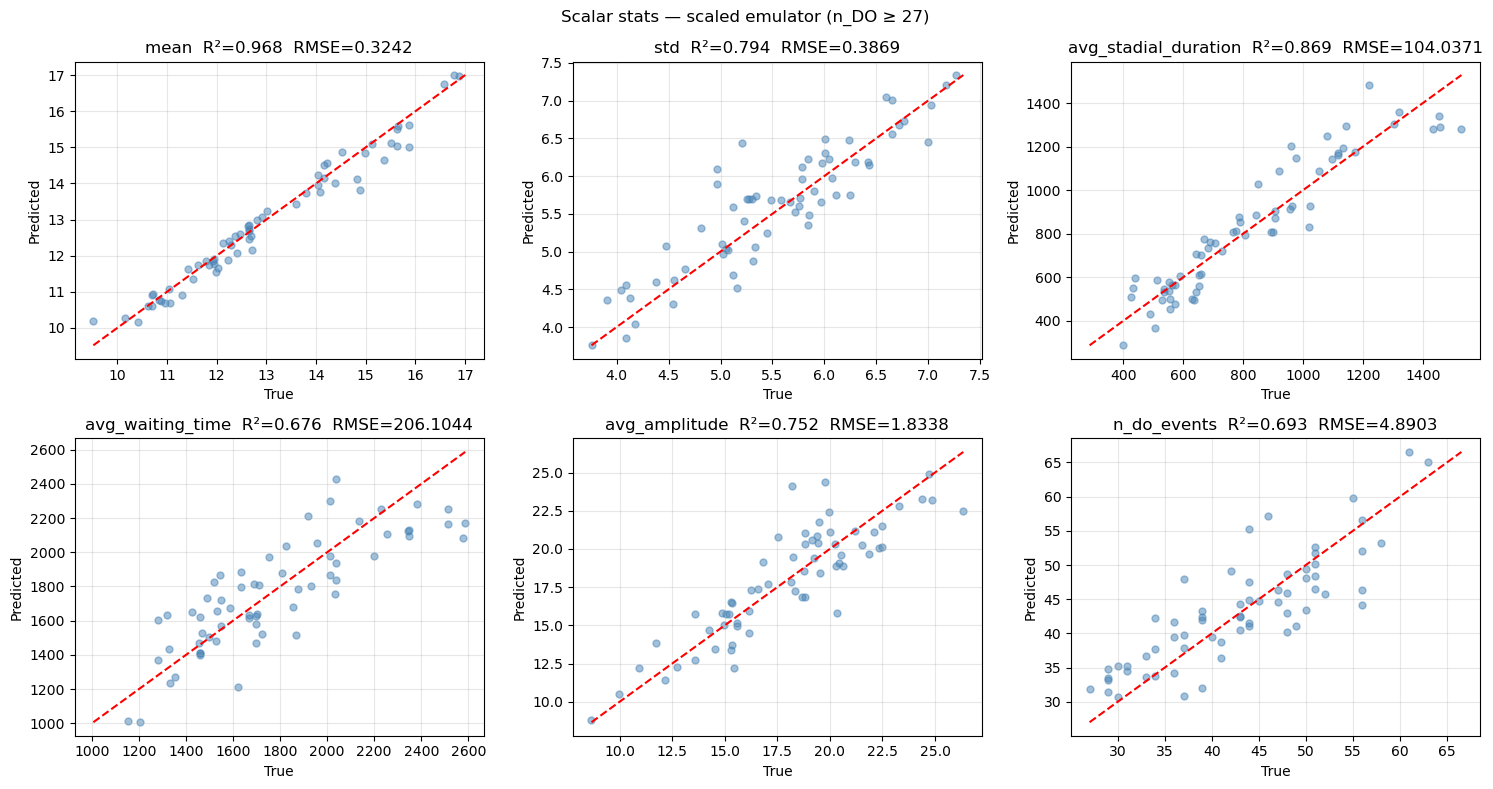

In [15]:
fig = plot_stat_predictions(Y_test, Y_pred, stat_names=STAT_COLS)
plt.suptitle(f'Scalar stats — scaled emulator (n_DO ≥ {N_DO_THRESHOLD})', fontsize=12)
plt.tight_layout()
plt.show()

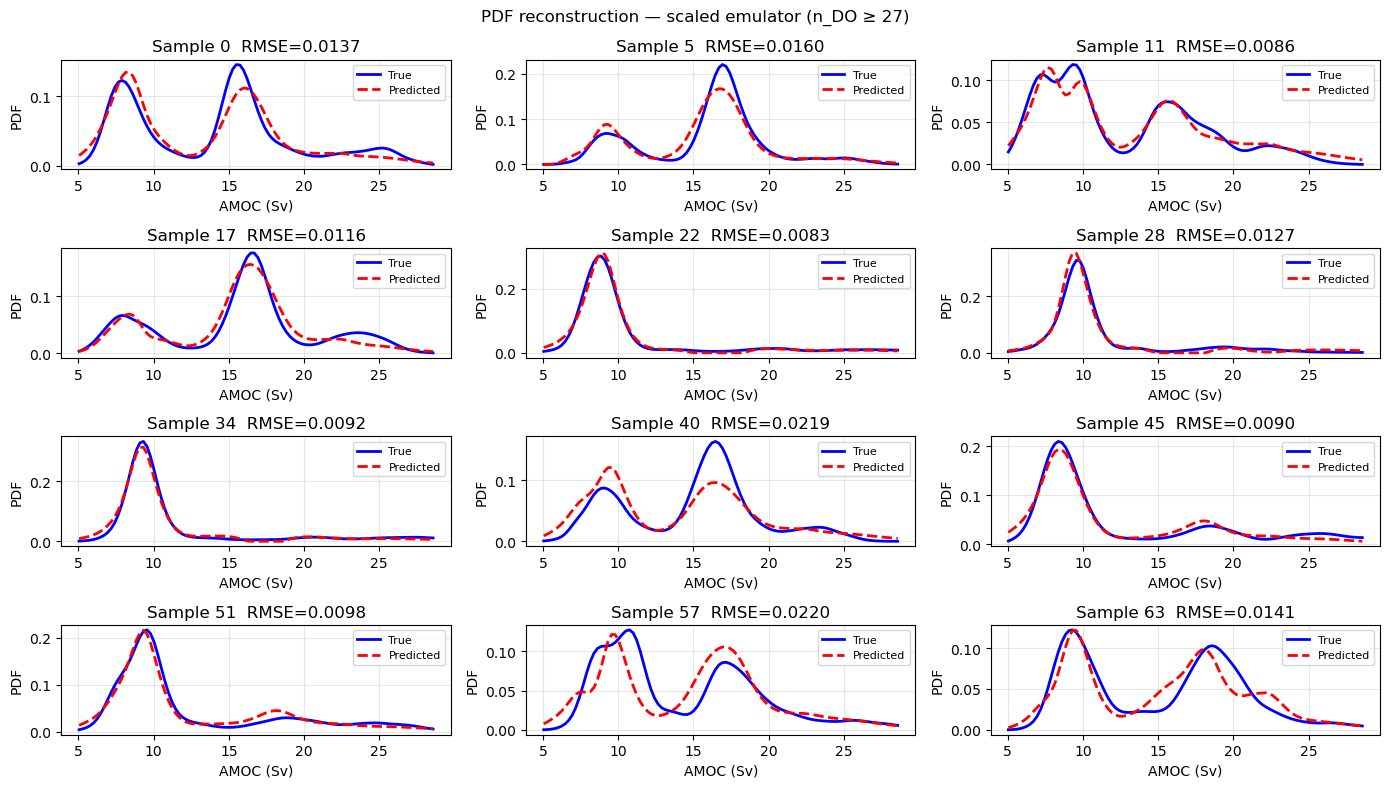

In [16]:
fig = plot_pdf_comparison(pdf_test, pdf_pred, global_x_grid, n_examples=12)
plt.suptitle(f'PDF reconstruction — scaled emulator (n_DO ≥ {N_DO_THRESHOLD})', fontsize=12)
plt.tight_layout()
plt.show()

### 4.5 Predict Default Run

Predicted vs true scalar stats for the default run:
Stat                         Predicted       ±std         True
--------------------------------------------------------------
mean                             12.71      0.463         12.6
std                              6.101       0.45        6.158
avg_stadial_duration             875.4      68.39        813.3
avg_waiting_time                  1533        283         1452
avg_amplitude                    19.44     0.9303        18.77
n_do_events                      49.02        4.8           51


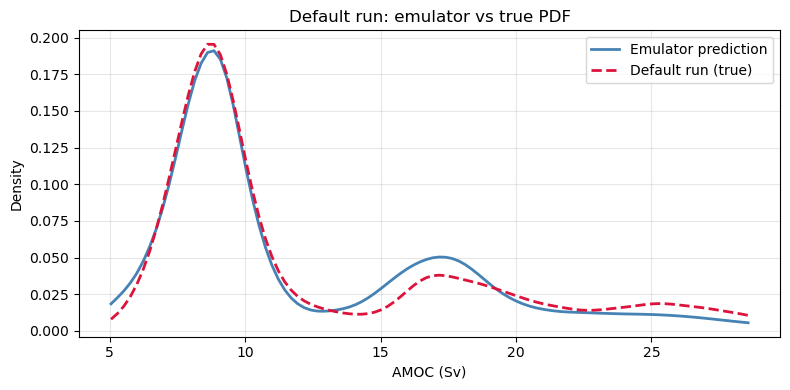

In [17]:
X_default = np.array([[1e-05, 3.0, 0.001, 1500.0, 1500.0, 0.00015]])

pca_pred_def, Y_pred_def, pca_std_def, Y_std_def = emulator.predict(
    X_default, return_std=True
)
pdf_pred_def = emulator.reconstruct_pdf(pca_pred_def)

print('Predicted vs true scalar stats for the default run:')
print(f'{"Stat":<25} {"Predicted":>12} {"±std":>10} {"True":>12}')
print('-' * 62)
for j, name in enumerate(STAT_COLS):
    true_val = default_stats[name] if default_stats is not None else float('nan')
    print(f'{name:<25} {Y_pred_def[0, j]:>12.4g} {Y_std_def[0, j]:>10.4g} {true_val:>12.4g}')

if default_stats is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(global_x_grid, pdf_pred_def.flatten(), label='Emulator prediction', color='steelblue', lw=2)
    ax.plot(global_x_grid, default_stats['pdf'], label='Default run (true)', color='crimson', lw=2, ls='--')
    ax.set_xlabel('AMOC (Sv)')
    ax.set_ylabel('Density')
    ax.set_title('Default run: emulator vs true PDF')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. MCMC in [0, 1] Space

### 5.1 ScaledEmulatorMCMC

Differences from `EmulatorMCMC` in `mcmc.py`:

| | `EmulatorMCMC` | `ScaledEmulatorMCMC` |
|---|---|---|
| Sampling space | log-space φ = log θ | normalised u ∈ [0,1]^6 |
| Prior | KDE on training samples + log-Jacobian | KDE on training samples (no Jacobian needed — constant w.r.t. u) |
| Bounds | log(lower), log(upper) | 0, 1 |

The KDE is built in physical parameter space from the filtered training set
(n_DO ≥ 20) and evaluated at θ = lower + u·(upper − lower).
The Jacobian of the u → θ change of variables is constant (diagonal matrix
with entries upper − lower), so it only shifts log p by a constant that
cancels in MCMC acceptance ratios — no correction needed.

In [18]:
import warnings
from scipy.stats import gaussian_kde, norm as _norm
warnings.filterwarnings('ignore')


class ScaledEmulatorMCMC:
    """
    MCMC with sampling directly in normalised [0, 1]^d parameter space.

    Prior   : marginal KDE on training parameters (physical space).
              Evaluated at theta = lower + u*(upper-lower); the Jacobian of
              the u->theta transform is constant and cancels in acceptance ratios.
    DO filter (optional):
              Adds log P(n_do_events >= do_n_threshold) to the log-posterior,
              using the emulator's predicted mean and a total std that folds in
              the CV RMSE.  This softly suppresses parameter combinations where
              the emulator predicts too few DO events, consistent with the
              training-data filter.
    Sampler : emcee.EnsembleSampler.
    """

    def __init__(self, emulator, stat_cols, prior_bounds,
                 obs_targets, obs_sigmas, prior_samples,
                 do_n_threshold=None, do_n_rmse=0.0,
                 nwalkers=64, discrepancy_sigmas=None):
        """
        Parameters
        ----------
        do_n_threshold : float or None
            If set, adds log P(n_do_events >= do_n_threshold) to the
            log-posterior.  Requires 'n_do_events' in stat_cols.
        do_n_rmse : float
            Extra uncertainty on the n_do_events prediction (e.g. CV RMSE).
            Combined in quadrature with the emulator's own predictive std.
        """
        self.emulator      = emulator
        self.stat_cols     = list(stat_cols)
        self.prior_bounds  = dict(prior_bounds)
        self.obs_targets   = dict(obs_targets)
        self.obs_sigmas          = dict(obs_sigmas)
        # Structural model error: gap between model and reality no parameter can close.
        # Zero (default) when calibrating to the model's own output.
        self.discrepancy_sigmas  = dict(discrepancy_sigmas) if discrepancy_sigmas else {}
        self.nwalkers            = nwalkers

        self.param_names = list(prior_bounds.keys())
        self.ndim        = len(self.param_names)

        self.lower = np.array([v[0] for v in prior_bounds.values()])
        self.upper = np.array([v[1] for v in prior_bounds.values()])

        self._prior_kde     = gaussian_kde(prior_samples.T)
        self._prior_samples = prior_samples.copy()

        # DO filter
        self._do_threshold = do_n_threshold
        self._do_rmse      = do_n_rmse
        if do_n_threshold is not None and 'n_do_events' not in self.stat_cols:
            raise ValueError("do_n_threshold requires 'n_do_events' in stat_cols.")

        self._pca_keys  = sorted(
            [k for k in obs_targets if k.startswith('pca_')],
            key=lambda k: int(k.split('_')[1]),
        )
        self._stat_keys = [k for k in obs_targets if not k.startswith('pca_')]
        self._stat_idx  = {k: self.stat_cols.index(k) for k in self._stat_keys}

        self.sampler        = None
        self._samples_u     = None
        self._samples_theta = None
        self._burn_in       = None
        self._thin          = None

    # -- coordinate transform -------------------------------------------------

    def _u_to_theta(self, u):
        return np.asarray(u, dtype=float) * (self.upper - self.lower) + self.lower

    # -- prior ----------------------------------------------------------------

    def log_prior(self, u):
        u = np.asarray(u, dtype=float)
        if np.any(u < 0.0) or np.any(u > 1.0):
            return -np.inf
        theta   = self._u_to_theta(u)
        kde_val = self._prior_kde(theta.reshape(-1, 1))[0]
        if kde_val <= 0.0:
            return -np.inf
        return np.log(kde_val)

    # -- likelihood + DO filter -----------------------------------------------

    def log_likelihood(self, u):
        theta = self._u_to_theta(u).reshape(1, -1)
        pca_p, Y_p, pca_s, Y_s = self.emulator.predict(theta, return_std=True)
        pca_p, pca_s = pca_p.flatten(), pca_s.flatten()
        Y_p,   Y_s   = Y_p.flatten(),   Y_s.flatten()

        ll = 0.0

        # Gaussian likelihood for calibration targets
        for key in self._pca_keys:
            i   = int(key.split('_')[1])
            var = (pca_s[i]**2
                   + self.obs_sigmas[key]**2
                   + self.discrepancy_sigmas.get(key, 0.0)**2)
            ll -= 0.5 * ((self.obs_targets[key] - pca_p[i])**2 / var
                         + np.log(2.0 * np.pi * var))

        for key in self._stat_keys:
            j   = self._stat_idx[key]
            var = (Y_s[j]**2
                   + self.obs_sigmas[key]**2
                   + self.discrepancy_sigmas.get(key, 0.0)**2)
            ll -= 0.5 * ((self.obs_targets[key] - Y_p[j])**2 / var
                         + np.log(2.0 * np.pi * var))

        # Soft DO filter:
        # log P(n_do_events >= threshold) under the emulator's predictive
        # distribution for n_do_events, with total std = sqrt(gp_std^2 + rmse^2).
        #
        #   log norm.cdf((mean - threshold) / std)  ->  0  when mean >> threshold
        #                                           -> -inf when mean << threshold
        #
        # Penalises parameter regions the emulator predicts will have too few
        # DO events, while remaining smooth across the boundary.
        if self._do_threshold is not None:
            j_ndo     = self.stat_cols.index('n_do_events')
            n_do_mean = Y_p[j_ndo]
            n_do_std  = np.sqrt(Y_s[j_ndo]**2 + self._do_rmse**2)
            ll += _norm.logcdf((n_do_mean - self._do_threshold) / n_do_std)

        return ll

    # -- posterior ------------------------------------------------------------

    def log_posterior(self, u):
        lp = self.log_prior(u)
        if not np.isfinite(lp):
            return -np.inf
        ll = self.log_likelihood(u)
        return lp + ll if np.isfinite(ll) else -np.inf

    # -- run ------------------------------------------------------------------

    def run(self, n_steps=10000, burn_in=1000, thin=10, seed=42, progress=True):
        import emcee

        rng    = np.random.default_rng(seed)
        u_init = rng.uniform(0.0, 1.0, (self.nwalkers, self.ndim))

        bad = [i for i in range(self.nwalkers)
               if not np.isfinite(self.log_posterior(u_init[i]))]
        if bad:
            print(f'  {len(bad)} walkers outside support at init -- resampling...')
            for i in bad:
                for _ in range(1000):
                    u_init[i] = rng.uniform(0.0, 1.0, self.ndim)
                    if np.isfinite(self.log_posterior(u_init[i])):
                        break

        do_str = (f', DO filter: n_do >= {self._do_threshold} (rmse={self._do_rmse})'
                  if self._do_threshold is not None else ', no DO filter')
        print(f'emcee: {self.nwalkers} walkers x {n_steps} steps  '
              f'(burn-in {burn_in}, thin {thin}{do_str})')
        print(f'Likelihood terms: {self._pca_keys + self._stat_keys}\n')

        self.sampler = emcee.EnsembleSampler(
            self.nwalkers, self.ndim, self.log_posterior
        )
        self.sampler.run_mcmc(u_init, n_steps, progress=progress)

        self._burn_in     = burn_in
        self._thin        = thin
        self._samples_u   = self.sampler.get_chain(
            discard=burn_in, thin=thin, flat=True
        )
        self._samples_theta = self._u_to_theta(self._samples_u)
        return self

    # -- posterior access -----------------------------------------------------

    @property
    def samples(self):
        if self._samples_theta is None:
            raise RuntimeError('Call run() first.')
        return self._samples_theta

    @property
    def samples_normalised(self):
        if self._samples_u is None:
            raise RuntimeError('Call run() first.')
        return self._samples_u

    # -- diagnostics ----------------------------------------------------------

    def convergence_diagnostics(self):
        acc = self.sampler.acceptance_fraction
        n_s = self._samples_u.shape[0]
        print('=' * 55)
        print('CONVERGENCE DIAGNOSTICS')
        print('=' * 55)
        print(f'Posterior samples      : {n_s}')
        print(f'Acceptance fraction    : {acc.mean():.3f}  '
              f'[{acc.min():.3f} - {acc.max():.3f}]  (ideal: 0.2-0.5)')
        try:
            tau = self.sampler.get_autocorr_time(quiet=True)
            print('\nIntegrated autocorr. time tau (steps):')
            for name, t in zip(self.param_names, tau):
                warn = '  chain too short' if n_s < 50 * t else ''
                print(f'  {name:<22}: {t:6.1f}{warn}')
            print(f'\nMean tau               : {tau.mean():.1f}')
            print(f'Effective samples (N/tau): {n_s / tau.mean():.0f}')
        except Exception as e:
            print(f'\nCould not estimate tau ({e}). Chain may be too short.')
        print('=' * 55)

    # -- chain traces ---------------------------------------------------------

    def plot_chains(self, figsize=None):
        chain = self.sampler.get_chain()
        logp  = self.sampler.get_log_prob()

        n_plots = self.ndim + 1
        figsize = figsize or (14, 2.2 * n_plots)
        fig, axes = plt.subplots(n_plots, 1, figsize=figsize, sharex=True)

        chain_phys = self._u_to_theta(
            chain.reshape(-1, self.ndim)
        ).reshape(chain.shape)

        for ax, name, i in zip(axes, self.param_names, range(self.ndim)):
            ax.plot(chain_phys[:, :, i], color='steelblue', alpha=0.1, lw=0.4)
            ax.set_ylabel(name, fontsize=8)
            ax.axvline(self._burn_in, color='red', ls='--', lw=1, alpha=0.8)
            ax.grid(alpha=0.2)
            ax.tick_params(labelsize=7)

        axes[-1].plot(logp, color='darkorange', alpha=0.1, lw=0.4)
        axes[-1].set_ylabel('log P', fontsize=8)
        axes[-1].axvline(self._burn_in, color='red', ls='--', lw=1,
                         label=f'burn-in ({self._burn_in})')
        axes[-1].legend(fontsize=8, loc='upper right')
        axes[-1].set_xlabel('Step')
        axes[-1].grid(alpha=0.2)

        plt.suptitle('MCMC Chains (physical parameter space)', fontsize=12)
        plt.tight_layout()
        return fig

    # -- 1-D marginal posteriors ----------------------------------------------

    def plot_posterior_1d(self, figsize=None, bins=40):
        n_cols  = 3
        n_rows  = int(np.ceil(self.ndim / n_cols))
        figsize = figsize or (5 * n_cols, 3.5 * n_rows)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
        axes = np.array(axes).flatten()

        for i, (ax, name) in enumerate(zip(axes, self.param_names)):
            lo, hi = self.lower[i], self.upper[i]
            grid   = np.linspace(lo, hi, 300)

            prior_k = gaussian_kde(self._prior_samples[:, i])
            prior_d = prior_k(grid)
            prior_d /= np.trapezoid(prior_d, grid)
            ax.fill_between(grid, prior_d, alpha=0.3, color='gray', label='Prior (KDE)')
            ax.plot(grid, prior_d, color='gray', lw=1)

            ax.hist(self.samples[:, i], bins=bins, density=True,
                    alpha=0.75, color='steelblue', label='Posterior', zorder=2)

            q16, med, q84 = np.percentile(self.samples[:, i], [16, 50, 84])
            ax.axvline(med, color='steelblue', lw=2)
            ax.axvspan(q16, q84, alpha=0.2, color='steelblue')

            ax.axvline(lo, color='dimgray', ls=':', lw=1)
            ax.axvline(hi, color='dimgray', ls=':', lw=1)

            ax.set_title(f'{name}\n{med:.3g}  [{q16:.3g}, {q84:.3g}]', fontsize=9)
            ax.set_xlabel(name, fontsize=8)
            ax.set_ylabel('Density', fontsize=8)
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)

        for j in range(self.ndim, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('Marginal Posteriors with KDE Prior', fontsize=13)
        plt.tight_layout()
        return fig

    # -- corner plot ----------------------------------------------------------

    def plot_corner(self, **kwargs):
        import corner
        fig = corner.corner(
            self.samples,
            labels=self.param_names,
            show_titles=True,
            title_fmt='.3g',
            quantiles=[0.16, 0.5, 0.84],
            **kwargs,
        )
        return fig

    # -- posterior predictive -------------------------------------------------

    def posterior_predictive(self, n_samples=100, seed=0):
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(self.samples),
                         size=min(n_samples, len(self.samples)), replace=False)

        pred_pdfs, pred_stats, pred_pca = [], [], []
        for theta in self.samples[idx]:
            pca_p, Y_p = self.emulator.predict(
                theta.reshape(1, -1), return_std=False
            )
            pred_pdfs.append(self.emulator.reconstruct_pdf(pca_p).flatten())
            pred_stats.append(Y_p.flatten())
            pred_pca.append(pca_p.flatten())

        return np.array(pred_pdfs), np.array(pred_stats), np.array(pred_pca)


print('ScaledEmulatorMCMC class defined.')

ScaledEmulatorMCMC class defined.


### 5.2 Train Inference Emulator & Configure MCMC

In [19]:
# ── MCMC configuration ────────────────────────────────────────────────────────
MCMC_N_STEPS  = 12000
MCMC_BURN_IN  = 5000
MCMC_THIN     = 10
MCMC_NWALKERS = 64

# Observational uncertainties (same as main notebook)
# Per-component obs uncertainty from window analysis (10k yr windows)
SIGMA_PCA_OBS = np.array([0.07, 0.04, 0.015, 0.032, 0.005])

# Per-statistic obs uncertainty from window analysis (10k yr windows)
SIGMA_STAT_OBS = {
    'avg_waiting_time':     230,   # yr
    'avg_stadial_duration': 177,   # yr
    'avg_amplitude':          2.4, # Sv
    'mean':                   0.25,# Sv
    'std':                    0.14,# Sv
    'n_do_events':            1.0, # count
}

# Likelihood targets: PCA 0-4 + avg_waiting_time
MCMC_STAT_TARGETS = ['avg_waiting_time']

# DO filter: soft threshold on predicted n_do_events.
# DO_N_RMSE folds in the CV RMSE (4.8) so the threshold has appropriate width;
# set to 0.0 to use only the GP's own predictive std.
DO_N_RMSE = 4.8   # from 5-fold CV

# Per-output std floor from CV RMSE — prevents GP overconfidence.
# Order: [pca_0..pca_4, mean, std, avg_stadial_dur, avg_waiting_time, avg_amp, n_do]
CV_RMSE_PCA  = np.array([0.0838, 0.0435, 0.0556, 0.0488, 0.0302])
CV_RMSE_STAT = np.array([0.41,   0.45,   0.0,    283.0,  0.0,       4.8])
MIN_STD = np.concatenate([CV_RMSE_PCA, CV_RMSE_STAT])

# ── Full-data emulator for inference (all n_DO >= 20 runs, no held-out fold) ──
emulator_mcmc = GPEmulatorPDF(
    kernel=1.0 * Matern(length_scale=1.0, nu=1.5),
    scaler_X=BoundsScaler(lower, upper),
    scaler_y=StandardScaler(),
    min_std=MIN_STD,
)
emulator_mcmc.pca         = pca_model
emulator_mcmc.pdf_xpoints = global_x_grid
emulator_mcmc.fit(X, other_stats, pca_components)

print(f'Inference emulator trained on {len(X)} runs  (n_DO >= {N_DO_THRESHOLD})')
print(f'MCMC: {MCMC_NWALKERS} walkers x {MCMC_N_STEPS} steps  '
      f'(burn-in {MCMC_BURN_IN}, thin {MCMC_THIN})')
print(f'DO filter: n_do >= {N_DO_THRESHOLD}, RMSE = {DO_N_RMSE}')


Inference emulator trained on 319 runs  (n_DO >= 27)
MCMC: 64 walkers x 12000 steps  (burn-in 5000, thin 10)
DO filter: n_do >= 27, RMSE = 4.8


In [20]:
# ── Calibration targets from the default run ──────────────────────────────────
obs_targets = {f'pca_{i}': default_stats['pca_components'][i] for i in range(N_PCA)}
for key in MCMC_STAT_TARGETS:
    obs_targets[key] = default_stats[key]

obs_sigmas = {f'pca_{i}': SIGMA_PCA_OBS[i] for i in range(N_PCA)}
for key in MCMC_STAT_TARGETS:
    obs_sigmas[key] = SIGMA_STAT_OBS[key]

print('Calibration targets:')
for k, v in obs_targets.items():
    print(f'  {k:<25}: {v:10.4f}  +-  {obs_sigmas[k]:.4f}')

# ── Instantiate ───────────────────────────────────────────────────────────────
mcmc = ScaledEmulatorMCMC(
    emulator=emulator_mcmc,
    stat_cols=STAT_COLS,
    prior_bounds=prior_bounds,
    obs_targets=obs_targets,
    obs_sigmas=obs_sigmas,
    prior_samples=X,
    do_n_threshold=N_DO_THRESHOLD,   # soft DO filter
    do_n_rmse=DO_N_RMSE,             # CV RMSE folded into filter width
    nwalkers=MCMC_NWALKERS,
)


Calibration targets:
  pca_0                    :     0.1659  +-  0.0700
  pca_1                    :    -0.0112  +-  0.0400
  pca_2                    :    -0.0193  +-  0.0150
  pca_3                    :    -0.0414  +-  0.0320
  pca_4                    :     0.0045  +-  0.0050
  avg_waiting_time         :  1451.9200  +-  230.0000


### 5.3 Run Sampler

In [21]:
mcmc.run(
    n_steps=MCMC_N_STEPS,
    burn_in=MCMC_BURN_IN,
    thin=MCMC_THIN,
    seed=42,
    progress=True,
)

print(f'\nPosterior sample shape: {mcmc.samples.shape}')
print('Parameter medians (physical space):')
for i, name in enumerate(mcmc.param_names):
    q16, med, q84 = np.percentile(mcmc.samples[:, i], [16, 50, 84])
    print(f'  {name:<22}: {med:.5g}  [{q16:.5g}, {q84:.5g}]')

emcee: 64 walkers x 12000 steps  (burn-in 5000, thin 10, DO filter: n_do >= 27 (rmse=4.8))
Likelihood terms: ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'avg_waiting_time']



100%|█████████████████████████████████████| 12000/12000 [02:41<00:00, 74.41it/s]


Posterior sample shape: (44800, 6)
Parameter medians (physical space):
  diff_dia_min          : 9.7818e-06  [8.3472e-06, 1.1443e-05]
  drag_topo_fac         : 3.031  [2.8271, 3.2804]
  slope_max             : 0.0010614  [0.0008979, 0.0011827]
  diff_iso              : 1568  [1381.3, 1712.7]
  diff_gm               : 1492.8  [1297.9, 1674.8]
  diff_dia_max          : 0.00015257  [0.00013194, 0.00017035]


### 5.4 Convergence Diagnostics

In [22]:
mcmc.convergence_diagnostics()

CONVERGENCE DIAGNOSTICS
Posterior samples      : 44800
Acceptance fraction    : 0.384  [0.365 - 0.406]  (ideal: 0.2-0.5)

Integrated autocorr. time tau (steps):
  diff_dia_min          :  131.2
  drag_topo_fac         :  143.4
  slope_max             :  136.8
  diff_iso              :  135.2
  diff_gm               :  116.8
  diff_dia_max          :  133.4

Mean tau               : 132.8
Effective samples (N/tau): 337


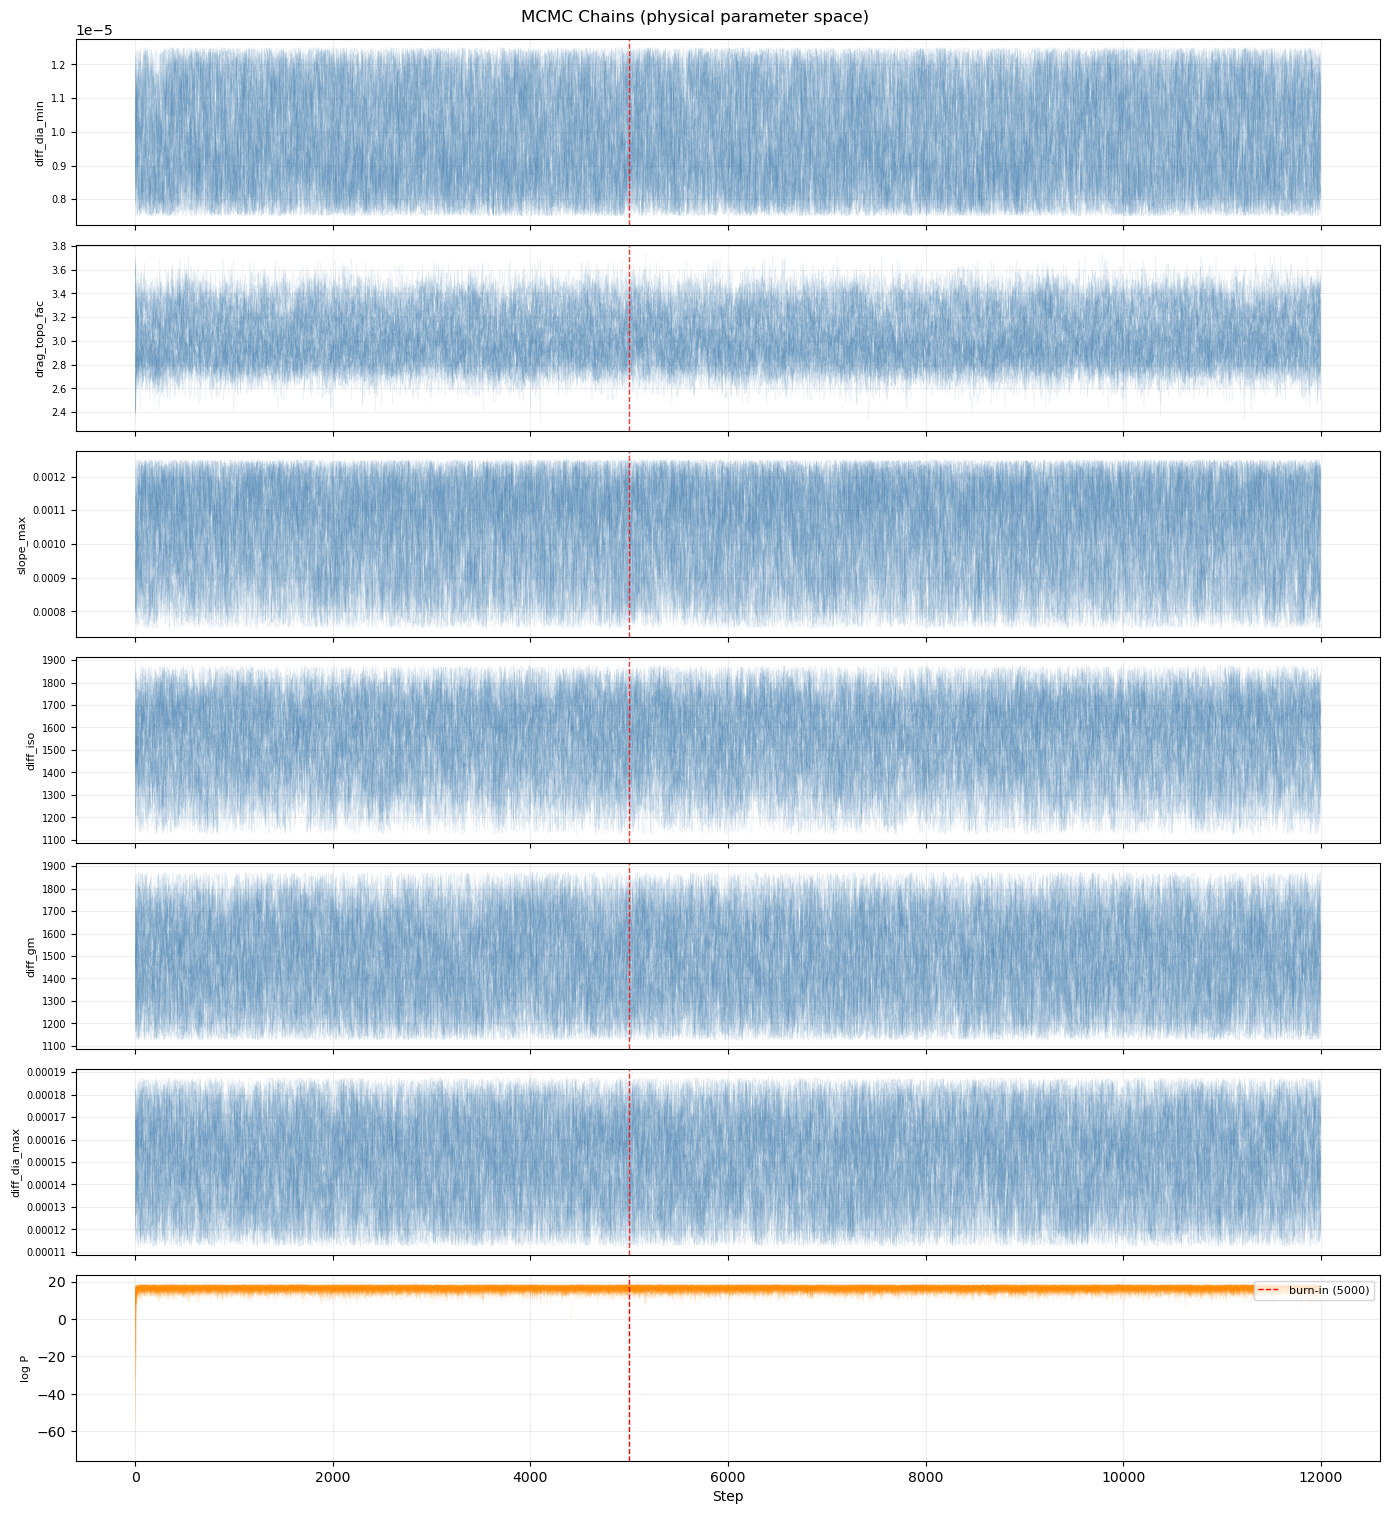

In [23]:
fig = mcmc.plot_chains()
plt.show()

### 5.5 Marginal Posteriors including penalties when n_DO(pred)<20

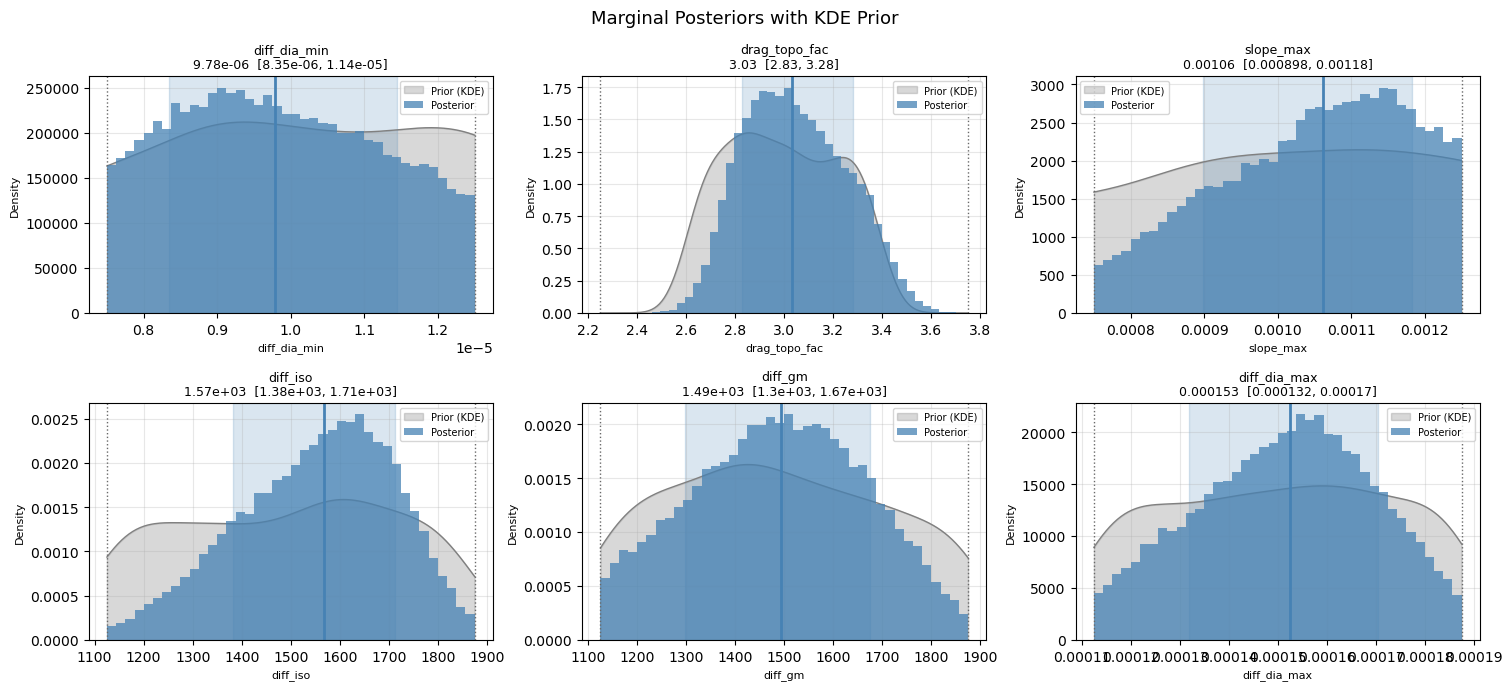

In [24]:
fig = mcmc.plot_posterior_1d()
plt.show()

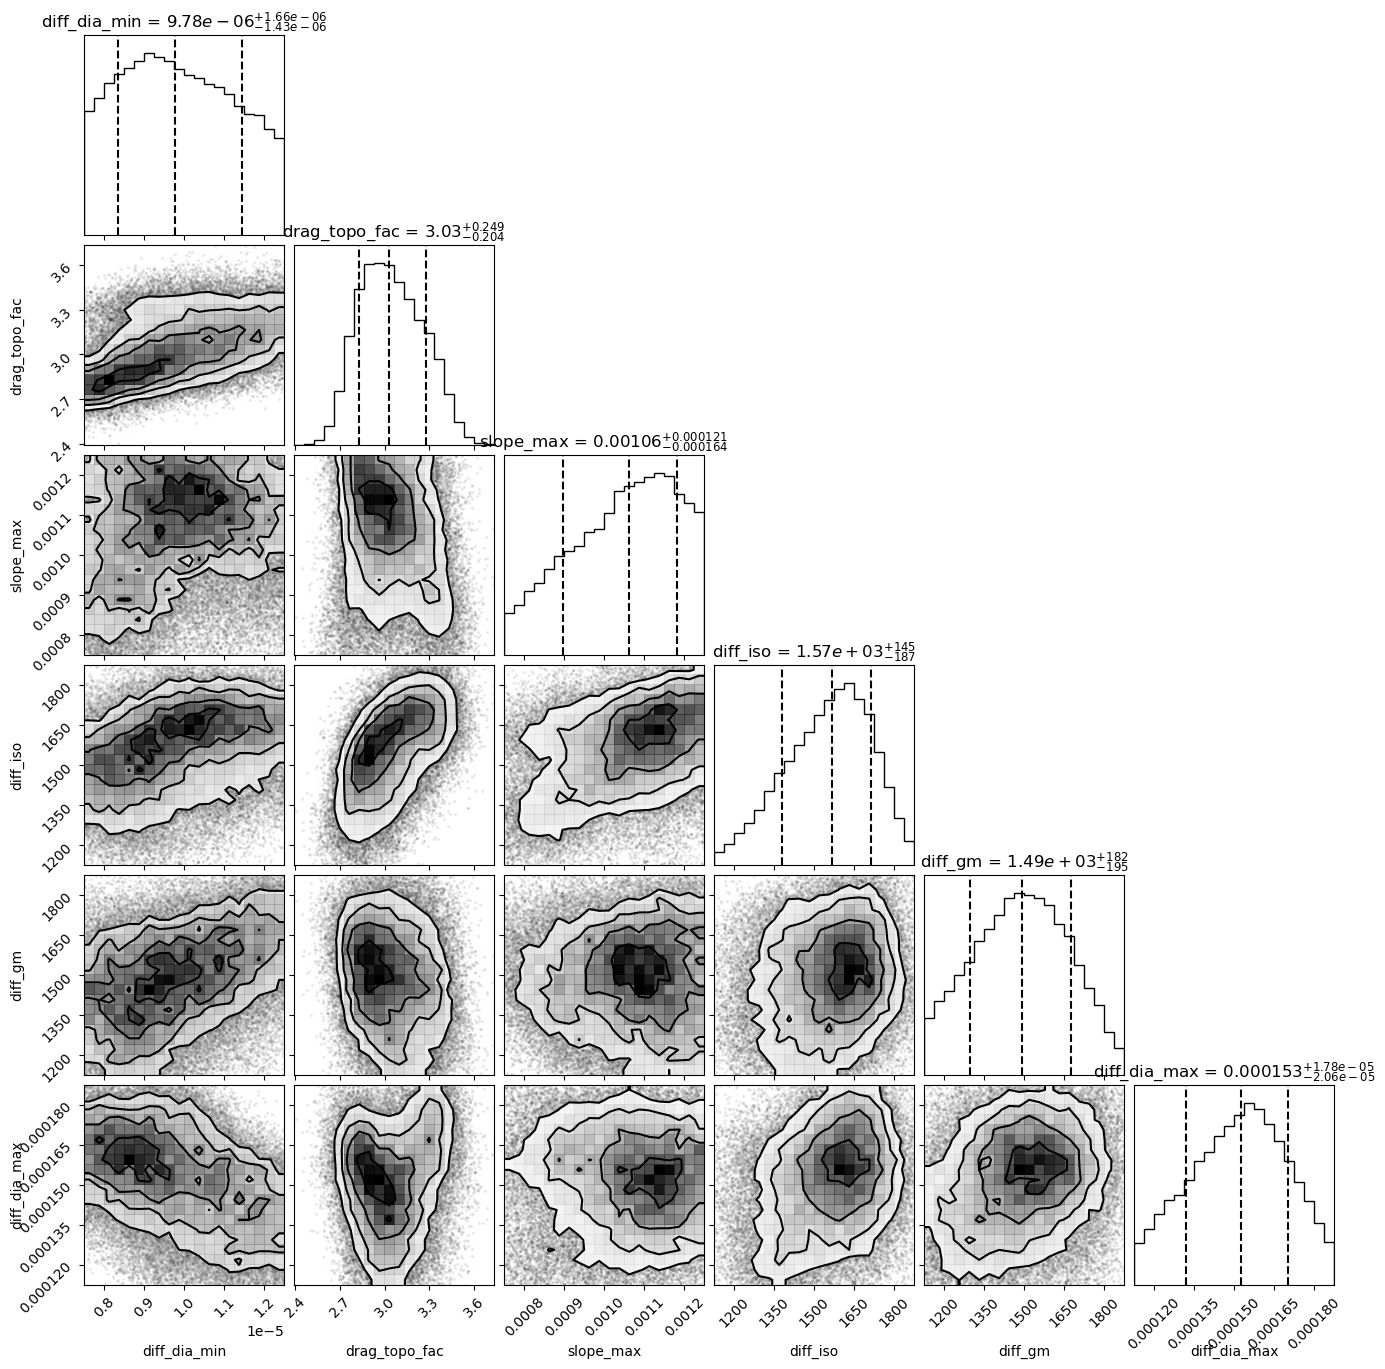

In [25]:
try:
    fig = mcmc.plot_corner()
    plt.show()
except ImportError:
    print("Install the 'corner' package for the joint posterior plot.")

### 5.6 Posterior Predictive

In [26]:
pred_pdfs, pred_stats, pred_pca = mcmc.posterior_predictive(n_samples=100, seed=0)
print(f'Posterior predictive samples: {len(pred_pdfs)}')

Posterior predictive samples: 100


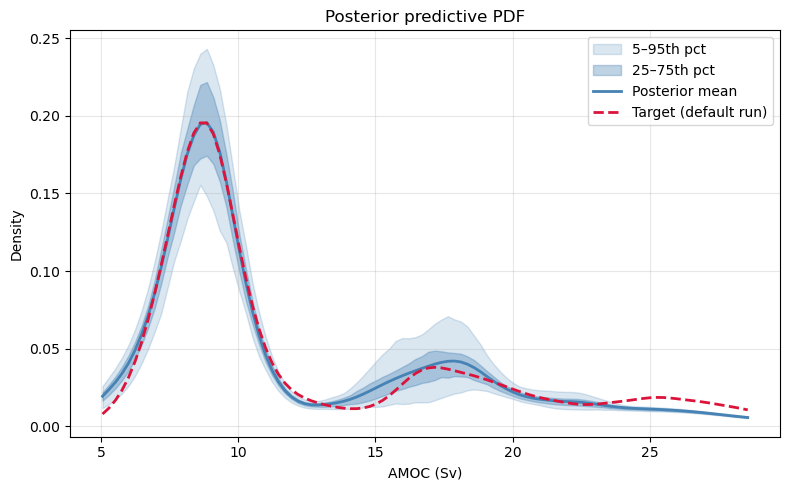

In [27]:
# ── PDF envelope ──────────────────────────────────────────────────────────────
mean_pdf = pred_pdfs.mean(0)
q5,  q95 = np.percentile(pred_pdfs, [ 5, 95], axis=0)
q25, q75 = np.percentile(pred_pdfs, [25, 75], axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(global_x_grid, q5,  q95,  alpha=0.20, color='steelblue', label='5–95th pct')
ax.fill_between(global_x_grid, q25, q75,  alpha=0.35, color='steelblue', label='25–75th pct')
ax.plot(global_x_grid, mean_pdf, color='steelblue', lw=2, label='Posterior mean')
if default_stats is not None:
    ax.plot(global_x_grid, default_stats['pdf'], color='crimson', lw=2, ls='--',
            label='Target (default run)')
ax.set_xlabel('AMOC (Sv)')
ax.set_ylabel('Density')
ax.set_title('Posterior predictive PDF')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

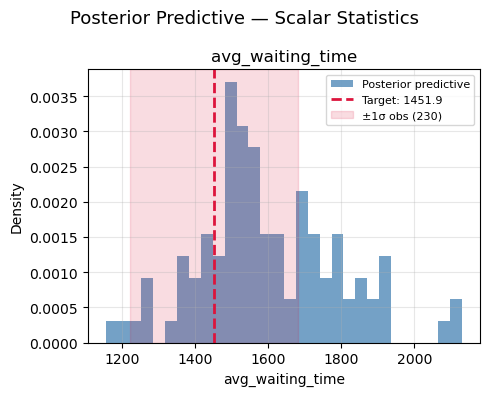

In [28]:
# ── Scalar stat histograms ────────────────────────────────────────────────────
stat_keys = [k for k in obs_targets if not k.startswith('pca_')]
n         = len(stat_keys)
fig, axes = plt.subplots(1, max(n, 1), figsize=(5 * max(n, 1), 4))
if n == 1:
    axes = [axes]

for ax, key in zip(axes, stat_keys):
    j      = STAT_COLS.index(key)
    vals   = pred_stats[:, j]
    target = obs_targets[key]
    sigma  = obs_sigmas.get(key)

    ax.hist(vals, bins=30, density=True, alpha=0.75,
            color='steelblue', label='Posterior predictive')
    ax.axvline(target, color='crimson', lw=2, ls='--',
               label=f'Target: {target:.1f}')
    if sigma is not None:
        ax.axvspan(target - sigma, target + sigma,
                   alpha=0.15, color='crimson', label=f'±1σ obs ({sigma:.0f})')
    ax.set_xlabel(key)
    ax.set_ylabel('Density')
    ax.set_title(key)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Posterior Predictive — Scalar Statistics', fontsize=13)
plt.tight_layout()
plt.show()

### 5.7 Threshold Sensitivity: Posterior Comparison

Run MCMC for three exclusion thresholds (`n_do_events ≥ 10 / 20 / 30`) and
overlay the 1-D marginal posteriors to diagnose how much the choice of
threshold affects the inferred parameter distributions.

Each emulator is trained from scratch on `X_do` filtered to the given
threshold, using the same `BoundsScaler` and `ScaledEmulatorMCMC` as the
main MCMC run. The DO soft-filter uses the same `DO_N_RMSE`.

In [29]:
COMPARE_THRESHOLDS = [10, 20, 30]
threshold_posteriors = {}   # {t: {'samples': ..., 'prior_samples': ...}}
n_do_col_cmp = STAT_COLS.index('n_do_events')

for t in COMPARE_THRESHOLDS:
    print(f'\n{"="*54}')
    print(f'  n_do_events \u2265 {t}')
    print(f'{"="*54}')

    keep_t  = Y_do[:, n_do_col_cmp] >= t
    X_t     = X_do[keep_t]
    Y_t     = Y_do[keep_t]
    pca_t   = pca_do[keep_t]
    print(f'  Training runs : {keep_t.sum()} / {len(X_do)}  ({(~keep_t).sum()} excluded)')

    em_t = GPEmulatorPDF(
        kernel=1.0 * Matern(length_scale=1.0, nu=1.5),
        scaler_X=BoundsScaler(lower, upper),
        scaler_y=StandardScaler(),
        min_std=MIN_STD,
    )
    em_t.pca         = pca_model
    em_t.pdf_xpoints = global_x_grid
    em_t.fit(X_t, Y_t, pca_t)

    obs_t = {f'pca_{i}': default_stats['pca_components'][i] for i in range(N_PCA)}
    for key in MCMC_STAT_TARGETS:
        obs_t[key] = default_stats[key]

    sig_t = {f'pca_{i}': SIGMA_PCA_OBS[i] for i in range(N_PCA)}
    for key in MCMC_STAT_TARGETS:
        sig_t[key] = SIGMA_STAT_OBS[key]

    mcmc_t = ScaledEmulatorMCMC(
        emulator=em_t,
        stat_cols=STAT_COLS,
        prior_bounds=prior_bounds,
        obs_targets=obs_t,
        obs_sigmas=sig_t,
        prior_samples=X_t,
        do_n_threshold=t,
        do_n_rmse=DO_N_RMSE,
        nwalkers=MCMC_NWALKERS,
    )
    mcmc_t.run(n_steps=MCMC_N_STEPS, burn_in=MCMC_BURN_IN, thin=MCMC_THIN,
               seed=42, progress=True)

    threshold_posteriors[t] = {
        'samples':       mcmc_t.samples,
        'prior_samples': X_t,
    }
    print(f'  Posterior samples : {mcmc_t.samples.shape[0]}')

print('\nAll threshold runs complete.')



  n_do_events ≥ 10
  Training runs : 392 / 431  (39 excluded)
emcee: 64 walkers x 12000 steps  (burn-in 5000, thin 10, DO filter: n_do >= 10 (rmse=4.8))
Likelihood terms: ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'avg_waiting_time']



100%|█████████████████████████████████████| 12000/12000 [02:52<00:00, 69.41it/s]


  Posterior samples : 44800

  n_do_events ≥ 20
  Training runs : 351 / 431  (80 excluded)
emcee: 64 walkers x 12000 steps  (burn-in 5000, thin 10, DO filter: n_do >= 20 (rmse=4.8))
Likelihood terms: ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'avg_waiting_time']



100%|█████████████████████████████████████| 12000/12000 [02:45<00:00, 72.64it/s]


  Posterior samples : 44800

  n_do_events ≥ 30
  Training runs : 296 / 431  (135 excluded)
emcee: 64 walkers x 12000 steps  (burn-in 5000, thin 10, DO filter: n_do >= 30 (rmse=4.8))
Likelihood terms: ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'avg_waiting_time']



100%|█████████████████████████████████████| 12000/12000 [02:40<00:00, 75.00it/s]

  Posterior samples : 44800

All threshold runs complete.


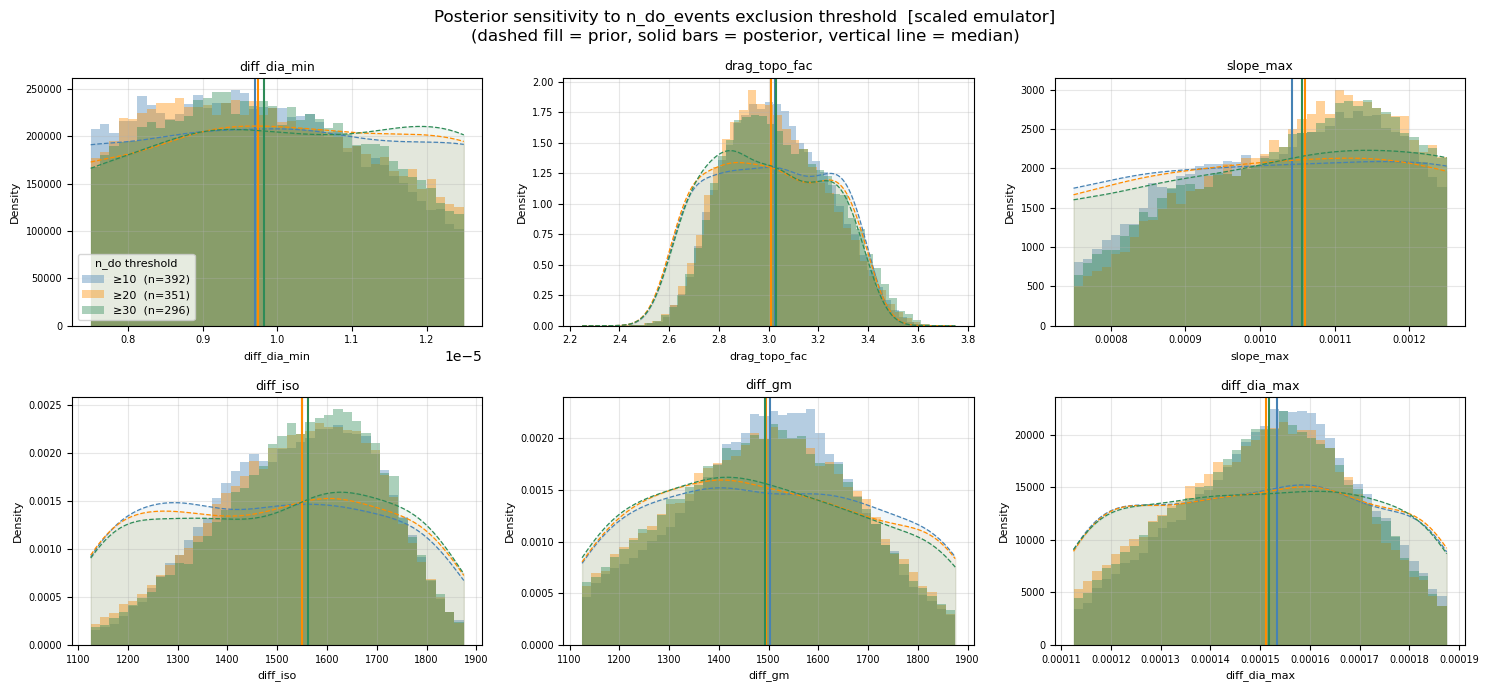

In [30]:
from scipy.stats import gaussian_kde as _gkde

n_cols = 3
n_rows = int(np.ceil(len(param_names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).flatten()

COMPARE_COLORS = {10: 'steelblue', 20: 'darkorange', 30: 'seagreen'}

for i, (ax, name) in enumerate(zip(axes, param_names)):
    lo, hi = prior_bounds[name]
    grid   = np.linspace(lo, hi, 300)

    for t, col in COMPARE_COLORS.items():
        pr_samps   = threshold_posteriors[t]['prior_samples']
        post_samps = threshold_posteriors[t]['samples']
        n_train    = len(pr_samps)

        # Prior marginal KDE (dashed fill)
        pr_k = _gkde(pr_samps[:, i])
        pr_d = pr_k(grid)
        pr_d /= np.trapezoid(pr_d, grid)
        ax.fill_between(grid, pr_d, alpha=0.07, color=col)
        ax.plot(grid, pr_d, color=col, lw=0.9, ls='--')

        # Posterior histogram
        ax.hist(post_samps[:, i], bins=40, density=True,
                alpha=0.40, color=col, label=f'\u2265{t}  (n={n_train})')

        # Posterior median
        ax.axvline(np.median(post_samps[:, i]), color=col, lw=1.5)

    ax.set_title(name, fontsize=9)
    ax.set_xlabel(name, fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8, title='n_do threshold', title_fontsize=8)

for j in range(len(param_names), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Posterior sensitivity to n_do_events exclusion threshold  [scaled emulator]\n'
    '(dashed fill = prior, solid bars = posterior, vertical line = median)',
    fontsize=12,
)
plt.tight_layout()
plt.show()
